OJO QUE ESTO ES UN POCO ABSURDO YA QUE PARA CALCULAR e USO $f(x) = e^{-x}$, lo cual tiene poco sentido, pero por practicar está bien.

In [11]:
import pandas as pd              # Para análisis de datos
import numpy as np               # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para gráficos
import seaborn as sns            # Para gráficos bonitos

La idea es sencilla. Si tenemos un cuadrado de tamaño $1 \times 1$ en $x \in [0,1]$ y en $y \in [0,1]$, y la función $f(x) = e^{-x}$ que atraviesa este cuadrado, entonces sabemos que $A_{T} = 1$ y que $A_{e} = \int_{0}^{1}e^{-x}dx = 1-e^{-1}$.

Si ahora generamos $N$ puntos dentro del cuadrado de $1x1$ y llamamos red ($R$) a todos aquellos que caen dentro del círculo y blue ($B$) a todos aquellos que están fuera, entonces sabemos que $R + B = N$ y que $1 = A_{T} = (R+B)/N = A_{e} + A_{resto}$, y por lo tanto $\rightarrow$

$e = \frac{1}{1-R/N}$. 

In [12]:
def rand(a,b,N):
    # [a,b] = rango de generacion
    # N = numero de puntos a generar

    x_rand = np.random.uniform(a,b,N) # Vector de puntos generados

    return x_rand

In [14]:
def e_x(x,y):

    val = y - np.e**(-x) # r^2 = x^2 + y^2

    return val

In [16]:
def E_MC(a,b,N):
    # [a,b] = rango de generacion
    # N = numero de puntos a generar

    x_rand = rand(a,b,N)
    y_rand = rand(a,b,N)

    Red = 0
    Blue = 0

    for k in range (0,N,1):
        if e_x(x_rand[k],y_rand[k]) <= 0: 
            Red = Red + 1
        else:
            Blue = Blue + 1

    nume = 1/(1-(Red/N))

    return Red,nume,x_rand,y_rand

In [23]:
a=0.0
b=1.0
N=2500

R,num_e,x_rand,y_rand = E_MC(a,b,N)

print('El valor de e estimado es de',num_e,'.')
print('El numero de puntos que hay por debajo de f(x) son',R,'de',N,'.')

El valor de e estimado es de 2.7262813522355507 .
El numero de puntos que hay por debajo de f(x) son 1583 de 2500 .


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


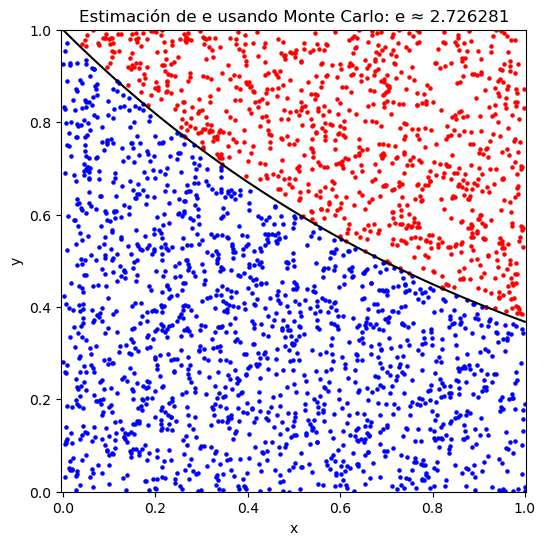

In [26]:
inside = y_rand - np.e**(-x_rand) <= 0.0 

# Crear la figura
plt.figure(figsize=(6,6))
plt.scatter(x_rand[inside], y_rand[inside], color='blue', s=5, label='Dentro de f')
plt.scatter(x_rand[~inside], y_rand[~inside], color='red', s=5, label='Fuera de f')

# Dibujar y = e^{-x}
x = np.linspace(0, 1, 100)
y = np.exp(-x)
plt.plot(x, y, label=r"$y = e^{-x}$", color="black")

plt.title(f'Estimación de e usando Monte Carlo: e ≈ {num_e:.6f}')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()